In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data/encoded_unsupervised.csv')

In [3]:
df.columns

Index(['id_student', 'highest_education', 'imd_band', 'age_band',
       'num_of_prev_attempts', 'studied_credits', 'date_registration',
       'avg_clicks_per_day', 'module_presentation_length',
       'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count',
       'avg_submission_delay', 'sites_revisit_ratio',
       'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC',
       'code_module_DDD', 'code_module_EEE', 'code_module_FFF',
       'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B',
       'code_presentation_2014J', 'gender_M', 'disability_Y'],
      dtype='str')

In [4]:
n_cols = len(df.columns)
print("Number of columns:", n_cols)

Number of columns: 26


In [5]:
import numpy as np

# df = your current feature-engineered dataset

eps = 1e-6  # prevents divide-by-zero

# 1) Late submission ratio (time-management discipline)
df['late_submission_ratio'] = df['late_submissions_count'] / (df['total_submissions'] + eps)

# 2) On-time submission ratio (reliability)
df['on_time_submission_ratio'] = 1 - df['late_submission_ratio']

# 3) Submissions per week (assessment consistency)
df['submissions_per_week'] = df['total_submissions'] / (df['module_presentation_length'] / 7 + eps)

# 4) Late submissions per week (chronic procrastination)
df['late_per_week'] = df['late_submissions_count'] / (df['module_presentation_length'] / 7 + eps)

# 5) Engagement per credit (effort relative to workload)
df['engagement_per_credit'] = df['avg_clicks_per_day'] / (df['studied_credits'] + eps)

# 6) Score per submission (efficiency of attempts)
df['score_per_submission'] = df['tma_cma_weighted_score'] / (df['total_submissions'] + eps)

# 7) Effort-to-score ratio (hard-working vs efficient learners)
df['effort_to_score_ratio'] = df['avg_clicks_per_day'] / (df['tma_cma_weighted_score'] + 1)

# 8) Procrastination index (severity of late behaviour)
df['procrastination_index'] = (
    df['late_submission_ratio'] * df['avg_submission_delay'].clip(lower=0)
)

# 9) Revision intensity (revision behaviour scaled by engagement)
df['revision_intensity'] = df['sites_revisit_ratio'] * df['avg_clicks_per_day']

# 10) Learning breadth score (diversity + engagement combined)
df['learning_breadth_score'] = df['activity_diversity_ratio'] * df['avg_clicks_per_day']

# Cleanup for clustering safety
new_cols = [
    'late_submission_ratio','on_time_submission_ratio','submissions_per_week','late_per_week',
    'engagement_per_credit','score_per_submission','effort_to_score_ratio','procrastination_index',
    'revision_intensity','learning_breadth_score'
]

df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

df[new_cols].head()


,late_submission_ratio,on_time_submission_ratio,submissions_per_week,late_per_week,engagement_per_credit,score_per_submission,effort_to_score_ratio,procrastination_index,revision_intensity,learning_breadth_score
0,-8.283661e+05,8.283671e+05,0.000000,-6.376980,0.255025,824000.0,0.419450,-0.000000e+00,-0.039385,0.283106
1,6.513253e+05,-6.513243e+05,0.000000,5.014073,132222.902941,654000.0,0.079941,0.000000e+00,0.060339,0.122355
2,1.325388e+00,-3.253879e-01,-4.811414,-6.376980,309506.981485,-0.0,0.309507,0.000000e+00,-0.038302,-0.081058
3,-8.283661e+05,8.283671e+05,0.000000,-6.376980,105179.523926,763000.0,0.059659,-0.000000e+00,0.153998,0.093302
4,1.584907e+06,-1.584906e+06,0.000000,12.201028,-147293.813000,550000.0,-0.095028,3.819731e+06,-0.095698,-0.085531


In [6]:
n_cols = len(df.columns)
print("Number of columns:", n_cols)

Number of columns: 36


In [7]:
df.columns

Index(['id_student', 'highest_education', 'imd_band', 'age_band',
       'num_of_prev_attempts', 'studied_credits', 'date_registration',
       'avg_clicks_per_day', 'module_presentation_length',
       'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count',
       'avg_submission_delay', 'sites_revisit_ratio',
       'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC',
       'code_module_DDD', 'code_module_EEE', 'code_module_FFF',
       'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B',
       'code_presentation_2014J', 'gender_M', 'disability_Y',
       'late_submission_ratio', 'on_time_submission_ratio',
       'submissions_per_week', 'late_per_week', 'engagement_per_credit',
       'score_per_submission', 'effort_to_score_ratio',
       'procrastination_index', 'revision_intensity',
       'learning_breadth_score'],
      dtype='str')

In [8]:
old_features = [
    'avg_clicks_per_day',
    'activity_diversity_ratio',
    'sites_revisit_ratio',
    'total_submissions',
    'avg_submission_delay'
    ]

new_features = [
    'late_submission_ratio',   
    'procrastination_index',
    'score_per_submission',
    'effort_to_score_ratio'
]



In [9]:
from sklearn.preprocessing import StandardScaler
df = df.set_index("id_student")

scaler_new = StandardScaler()
df[new_features] = scaler_new.fit_transform(df[new_features])

In [10]:
final_features = old_features + new_features
X = df[final_features]
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df[final_features]),
    index=df.index,            # id_student
    columns=final_features
)

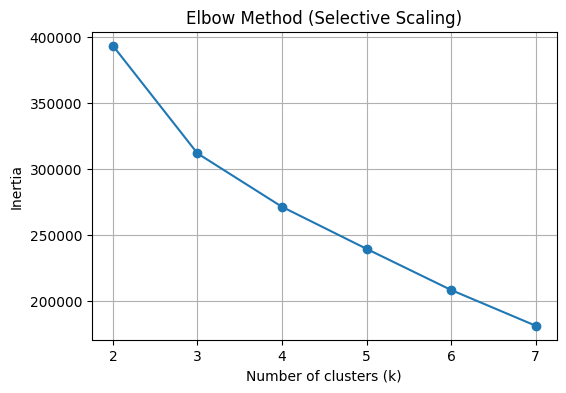

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Selective Scaling)")
plt.grid(True)
plt.show()


Silhouette scores for different k values:

k = 2 | silhouette score = 0.6966
k = 3 | silhouette score = 0.6208
k = 4 | silhouette score = 0.2676
k = 5 | silhouette score = 0.2704
k = 6 | silhouette score = 0.3193
k = 7 | silhouette score = 0.3528


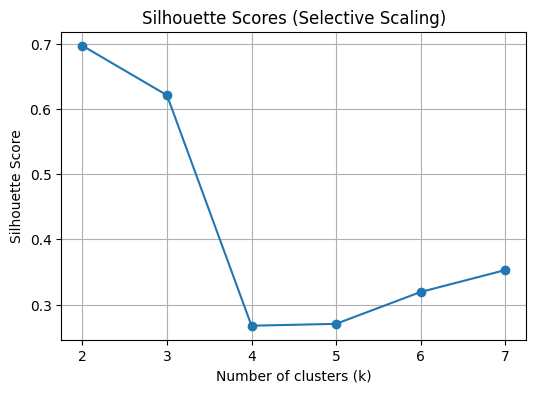

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
k_range = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [14]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X)

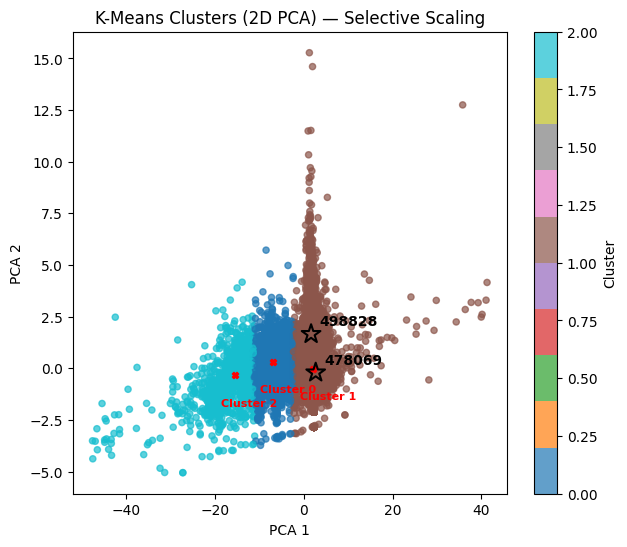

In [15]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=df['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA) — Selective Scaling")
plt.colorbar(label="Cluster")

for c in sorted(df['cluster'].unique()):
    idx = df['cluster'] == c
    x = X_pca2[idx, 0].mean()
    y = X_pca2[idx, 1].mean()
    plt.scatter(x, y, s=20, c='red', marker='X')  # Mark cluster centers
    plt.text(x-3, y-1.5, f'Cluster {c}', fontsize=8, weight='bold', color='red')

def highlight_student(student_id, annotate=True):
    loc = X_scaled.index.get_loc(student_id)

    if isinstance(loc, slice):
        i = loc.start
    elif np.isscalar(loc):
        i = int(loc)
    else:
        loc = np.asarray(loc)
        i = int(loc[0])

    x = float(X_pca2[i, 0])
    y = float(X_pca2[i, 1])

    plt.scatter(
        x, y,
        s=200,
        marker='*',
        facecolors='none',
        edgecolors='black',
        linewidths=1.5,
        zorder=10
    )

    if annotate:
        plt.annotate(
            str(student_id),
            (x, y),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=10,
            weight='bold',
            zorder=11
        )

highlight_student(498828)
highlight_student(478069)

plt.show()

C:\Users\Kevin\AppData\Local\Temp\ipykernel_18844\1217510700.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


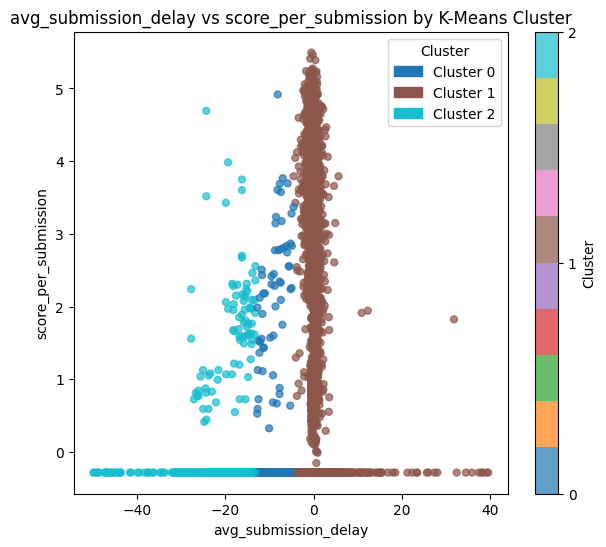

In [40]:

plt.figure(figsize=(7,6))
plt.scatter(
    df['avg_submission_delay'],
    df['score_per_submission'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('avg_submission_delay')
plt.ylabel('score_per_submission')
plt.title('avg_submission_delay vs score_per_submission by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\Kevin\AppData\Local\Temp\ipykernel_18844\3495097397.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


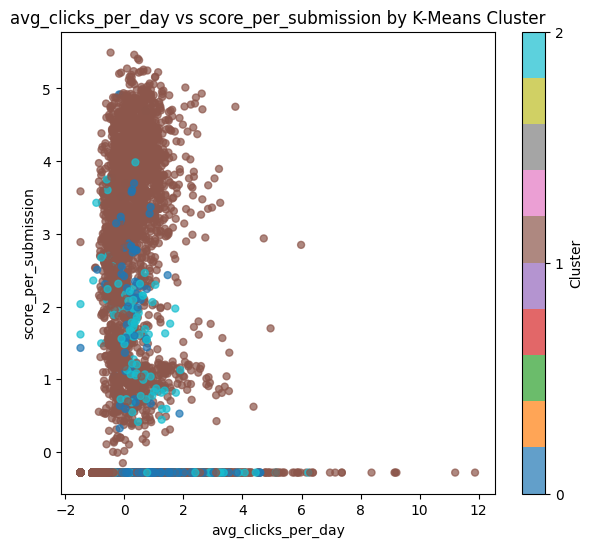

In [41]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['avg_clicks_per_day'],
    df['score_per_submission'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('avg_clicks_per_day')
plt.ylabel('score_per_submission')
plt.title('avg_clicks_per_day vs score_per_submission by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

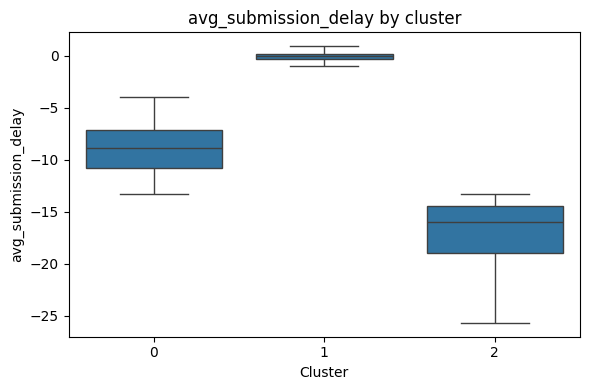

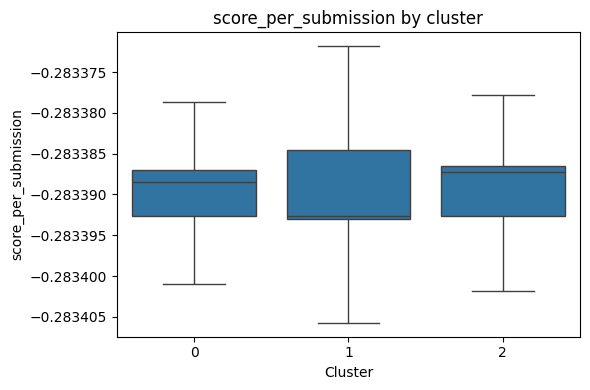

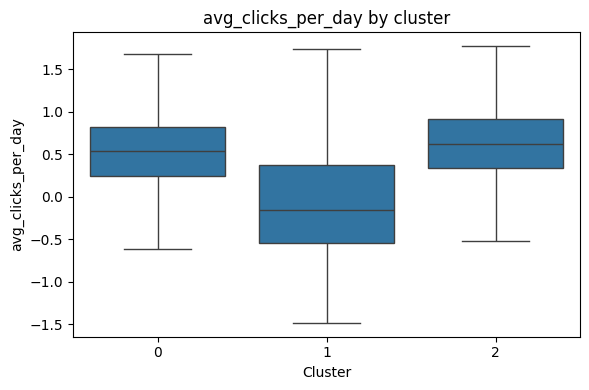

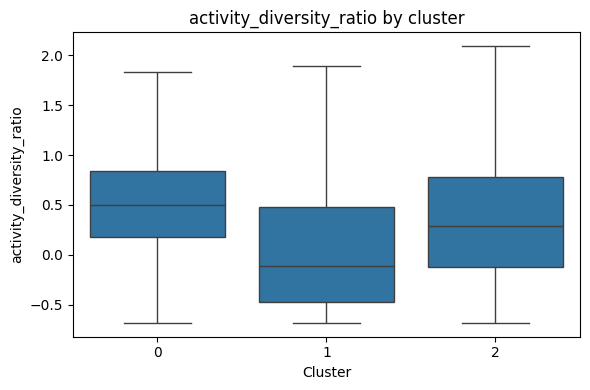

In [45]:
import seaborn as sns
features = ['avg_submission_delay', 'score_per_submission', 'avg_clicks_per_day', 'activity_diversity_ratio']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x='cluster',
        y=feature,
        data=df,
        showfliers=False
    )
    plt.title(f'{feature} by cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


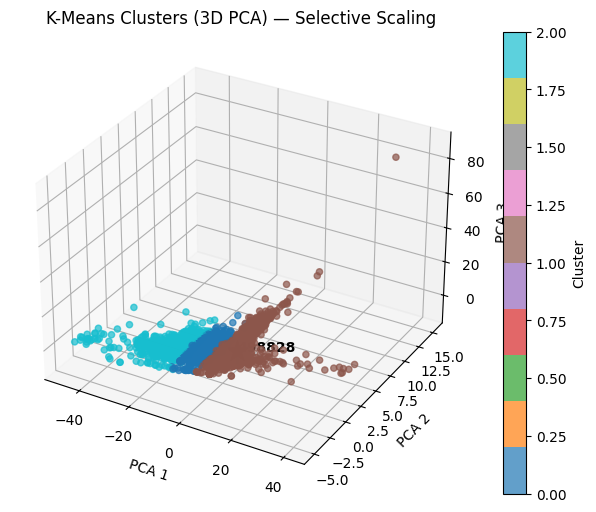

Explained variance (3D): 0.9170334434036695


In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2],
                c=df['cluster'], cmap='tab10', alpha=0.7, s=20)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("K-Means Clusters (3D PCA) — Selective Scaling")
plt.colorbar(sc, label="Cluster")

def highlight_student_3d(ax, student_id, X_pca3, index, annotate=True, draw_stem=True):
    """
    ax      : 3D axes (projection='3d')
    student_id : id_student
    X_pca3  : (n, 3) PCA result
    index   : match X_pca3 index
    """
    loc = index.get_loc(student_id)

    # loc 可能是 int / slice / bool-array / int-array
    if isinstance(loc, slice):
        i = loc.start
    elif np.isscalar(loc):
        i = int(loc)
    else:
        loc = np.asarray(loc)
        i = int(loc[0])

    x = float(X_pca3[i, 0])
    y = float(X_pca3[i, 1])
    z = float(X_pca3[i, 2])

    # highlight point
    ax.scatter(
        [x], [y], [z],
        s=260,
        marker='*',
        c='k',
        depthshade=False,
        zorder=10
    )

    # 可选：画“竖线”帮助定位（从当前 z 轴最低处拉到点）
    if draw_stem:
        z0 = ax.get_zlim()[0]
        ax.plot([x, x], [y, y], [z0, z], linewidth=2)

    # 可选：标注
    if annotate:
        ax.text(
            x, y, z,
            str(student_id),
            fontsize=10,
            fontweight='bold'
        )

    return (x, y, z)

highlight_student_3d(ax, 498828, X_pca3, index=X.index, annotate=True, draw_stem=True)
plt.show()

print("Explained variance (3D):", pca3.explained_variance_ratio_.sum())

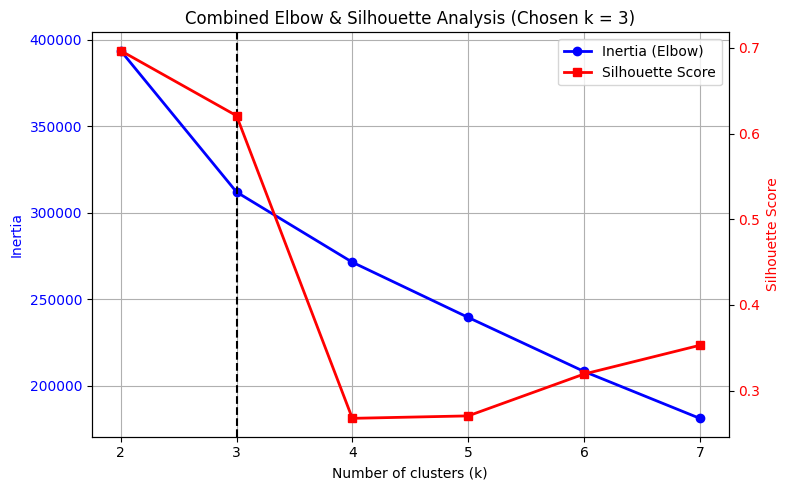

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 8)

inertia = []
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

chosen_k = 3

# ---- single combined plot ----
fig, ax1 = plt.subplots(figsize=(8, 5))

# Elbow curve – BLUE
ax1.plot(
    k_range,
    inertia,
    color='blue',
    marker='o',
    linewidth=2,
    label='Inertia (Elbow)'
)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.axvline(chosen_k, color='black', linestyle='--', linewidth=1.5)
ax1.grid(True)

# Silhouette curve – RED
ax2 = ax1.twinx()
ax2.plot(
    k_range,
    sil_scores,
    color='red',
    marker='s',
    linewidth=2,
    label='Silhouette Score'
)
ax2.set_ylabel("Silhouette Score", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Legend (manual so colours stay correct)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title("Combined Elbow & Silhouette Analysis (Chosen k = 3)")
plt.tight_layout()
plt.show()



In [18]:
import pandas as pd

cluster_profile = (
    df
    .groupby('cluster')[final_features]
    .mean()
    .round(3)
)

cluster_profile


,avg_clicks_per_day,activity_diversity_ratio,sites_revisit_ratio,total_submissions,avg_submission_delay,late_submission_ratio,procrastination_index,score_per_submission,effort_to_score_ratio
cluster,,,,,,,,,
0,0.543,0.512,0.339,0.572,-8.915,-0.034,-0.073,-0.247,0.594
1,-0.095,0.060,0.037,-0.063,-0.037,0.013,0.015,0.048,-0.128
2,0.637,0.350,0.463,0.472,-17.614,-0.131,-0.073,-0.186,0.624


In [19]:
cluster_profile_z = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

cluster_profile_z.round(2)


,avg_clicks_per_day,activity_diversity_ratio,sites_revisit_ratio,total_submissions,avg_submission_delay,late_submission_ratio,procrastination_index,score_per_submission,effort_to_score_ratio
cluster,,,,,,,,,
0,0.46,0.89,0.27,0.72,-0.01,0.23,-0.58,-0.76,0.54
1,-1.15,-1.08,-1.11,-1.14,1.00,0.87,1.15,1.13,-1.15
2,0.69,0.19,0.84,0.42,-1.00,-1.09,-0.58,-0.37,0.61


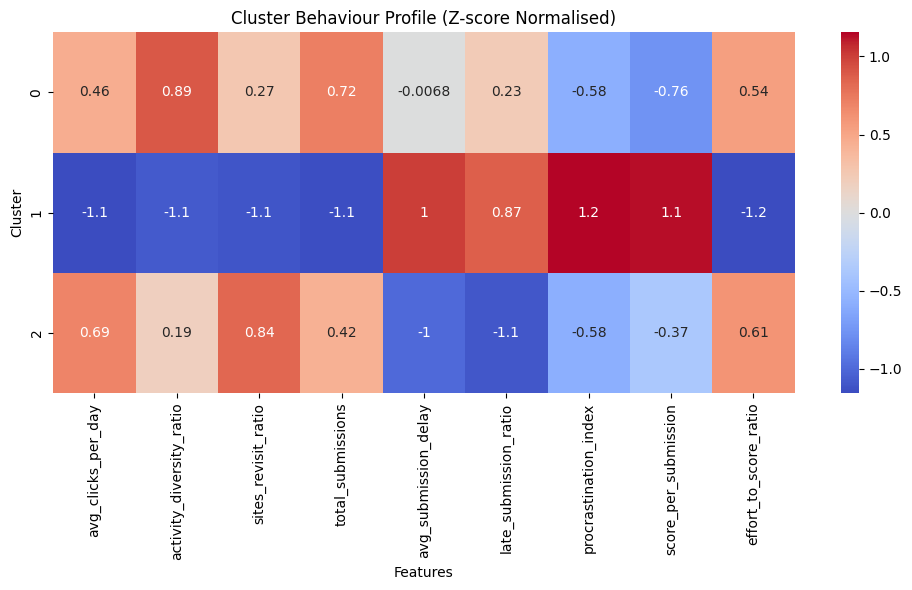

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profile_z,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Cluster Behaviour Profile (Z-score Normalised)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()
